# 08 · The Rosenblatt Perceptron

The perceptron (Rosenblatt, 1958) is the ancestor of every neural network: a
single **linear threshold unit**. It weights its inputs, sums them, and fires a
`1` when that sum crosses zero — otherwise `0`:

$$\hat{y} = \begin{cases} 1 & w \cdot x + b > 0 \\ 0 & \text{otherwise} \end{cases}$$

Training is famously simple. We show it one sample at a time and nudge the
weights only when it gets one wrong, using the **perceptron learning rule**:

$$w \leftarrow w + \alpha\,(y - \hat{y})\,x$$

A correct prediction leaves the weights untouched; a miss pushes them toward the
sample (when the label was `1`) or away from it (when it was `0`).

**The rule is not implemented anywhere.**
[`RosenblattPerceptron`](../src/dolcestat/neural_networks/perceptron.py) writes
none of that maths down. It assembles four ordinary pieces — a `DenseLayer` with
a `Step` activation, the `PerceptronCriterion` loss, a `MiniBatchSampler` of size
1, and plain `GradientDescent` — and the 1958 rule *falls out* of the
composition, exactly. The one trick that makes it work: the step function's true
derivative is zero everywhere, so `Step.backward` passes the gradient through
unchanged instead. That "straight-through" choice is what let the perceptron be
trained a decade before backpropagation existed.

## Linearly separable data

The perceptron can only draw a **straight** decision boundary, so we build a
problem it can actually solve: two classes split by the line
$x_1 + 1.5\,x_2 - 0.5 = 0$. We drop points too close to that line, leaving a
clean margin between the classes — i.e. a *linearly separable* dataset.


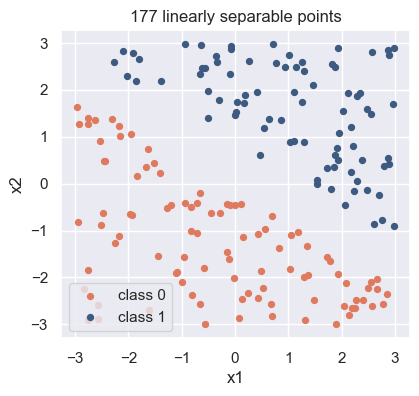

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from dolcestat.preprocessing import DolceSet
from dolcestat.neural_networks import RosenblattPerceptron

sns.set_theme()

rng = np.random.default_rng(0)
n = 200
X = rng.uniform(-3, 3, size=(n, 2))
score = 1.0 * X[:, 0] + 1.5 * X[:, 1] - 0.5   # signed distance to the true line
mask = np.abs(score) > 0.7                    # keep a margin -> separable
X, score = X[mask], score[mask]
y = (score > 0).astype(int)

df = pl.DataFrame({"x1": X[:, 0], "x2": X[:, 1], "label": y})
data = DolceSet()
data.load_from_polars_dataframe(df, target_col="label")

fig, ax = plt.subplots(figsize=(4.5, 4))
for cls, colour in [(0, "#e07a5f"), (1, "#3d5a80")]:
    pts = X[y == cls]
    ax.scatter(pts[:, 0], pts[:, 1], s=18, c=colour, label=f"class {cls}")
ax.set(xlabel="x1", ylabel="x2", title=f"{len(y)} linearly separable points")
ax.legend()
plt.show()


## Fit

We construct the unit with a learning rate `alpha`, then `fit` it with a budget
of `n_epochs` online updates. One sample is drawn per epoch, so here an epoch
*is* a single update — the unit the classic formulation counts. Because those
draws use NumPy's global RNG, we seed it for a reproducible run.

`predict` hands back a `ClassificationAnalyzer`, the same object every other
classifier in the library returns, so the usual metrics are available on it.

In [2]:
np.random.seed(0)

perceptron = RosenblattPerceptron(alpha=0.1).fit(data, n_epochs=500)

print("final weights [w1, w2]:", np.round(perceptron.weights.ravel(), 3))
print("final bias:", np.round(perceptron.bias, 3))
print("training accuracy:", perceptron.predict(data).accuracy(threshold=0.5))

final weights [w1, w2]: [0.28  0.514]
final bias: [-0.2]
training accuracy: 1.0


## Convergence

**Novikoff's theorem** (1962) guarantees that on linearly separable data the
perceptron stops making mistakes after a *finite* number of updates. We can
watch it happen: `history.epoch_loss` records the training **error rate** (the
fraction of misclassified points) after every update. It falls to exactly zero —
once the weights define a separating line, the learning rule stops changing
them.

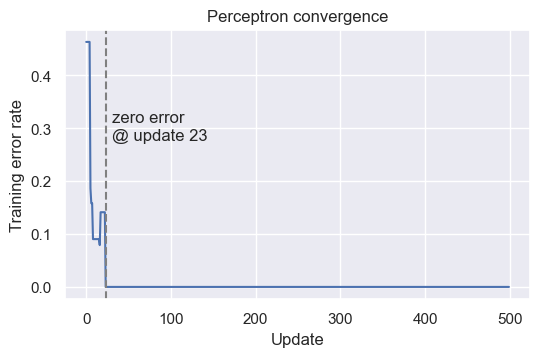

In [3]:
error_rate = perceptron.history.epoch_loss
first_zero = int(np.argmax(error_rate == 0)) if (error_rate == 0).any() else None

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.lineplot(x=range(len(error_rate)), y=error_rate, ax=ax)
if first_zero is not None:
    ax.axvline(first_zero, ls="--", c="grey")
    ax.text(first_zero + 8, error_rate.max() * 0.6, f"zero error\n@ update {first_zero}")
ax.set(xlabel="Update", ylabel="Training error rate", title="Perceptron convergence")
plt.show()

## Recap

A single linear unit, a one-line update rule, and a guarantee of convergence on
separable data — that's the whole perceptron. Its one limitation is also its
lesson: no straight line can separate every problem (XOR being the classic
counter-example), which is exactly what motivates stacking units into the deeper
networks that follow.
